In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
dir = 'data'

train_df = pd.read_pickle(f"{dir}/train_data.pkl")
test_df = pd.read_pickle(f"{dir}/test_data.pkl")

## EDA

In [7]:
train_metadata = train_df[['date', 'serial_number', 'model', 'capacity_bytes', 'failure']]

Text(0.5, 1.0, 'Top 20 Most Frequent Serial Numbers - 74453 Unique Drives')

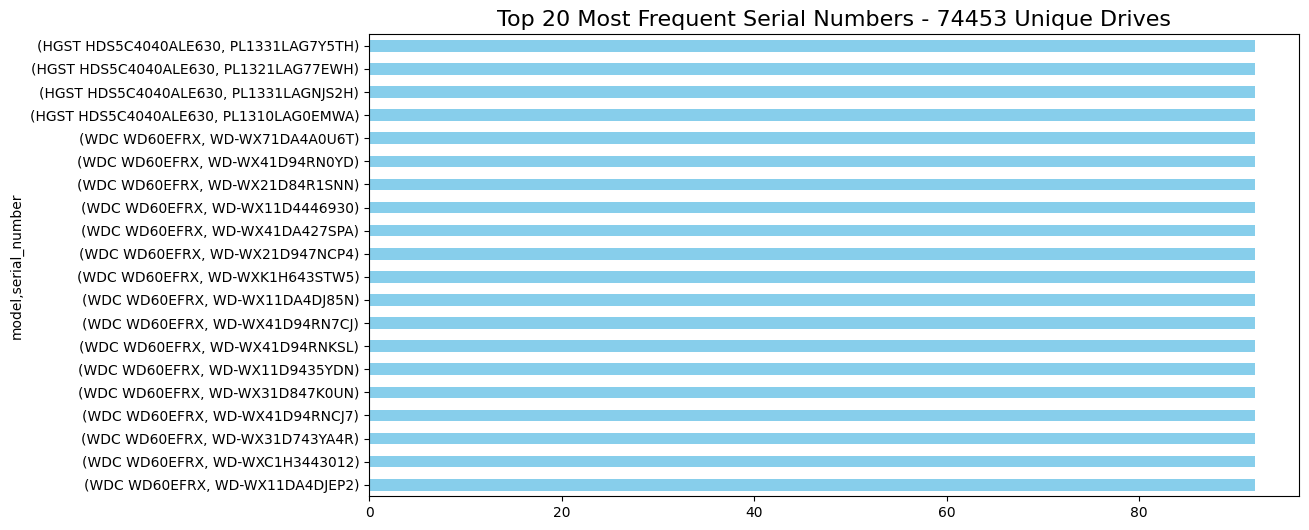

In [8]:
unique_drives =train_metadata['serial_number'].nunique()

train_metadata.groupby('model')["serial_number"].value_counts().sort_values(ascending=False).head(20).plot(kind='barh', figsize=(12,6), color='skyblue')
plt.title(f'Top 20 Most Frequent Serial Numbers - {unique_drives} Unique Drives', fontsize=16)

Text(0.5, 1.0, 'Top 20 Most Frequent Models - 59 Unique Models')

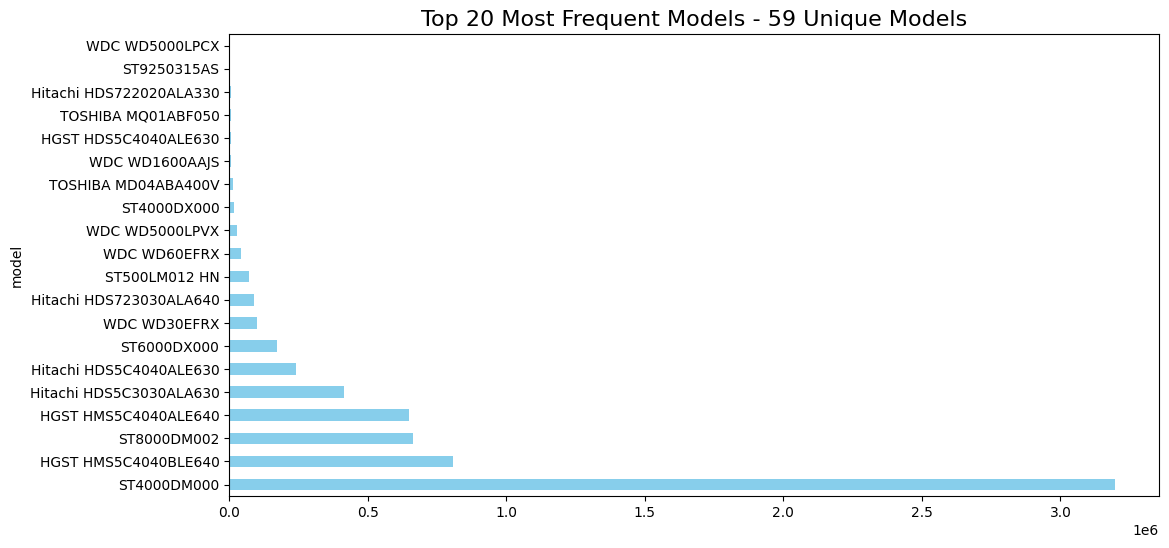

In [ ]:
unique_models =train_metadata['model'].nunique()

train_metadata.groupby('model')["model"].value_counts().sort_values(ascending=False).head(20).plot(kind='barh', figsize=(12,6), color='skyblue')
plt.title(f'Top 20 Most Frequent Models - {unique_models} Unique Models', fontsize=16)

Text(0.5, 1.0, 'Top 10 Least Frequent Models')

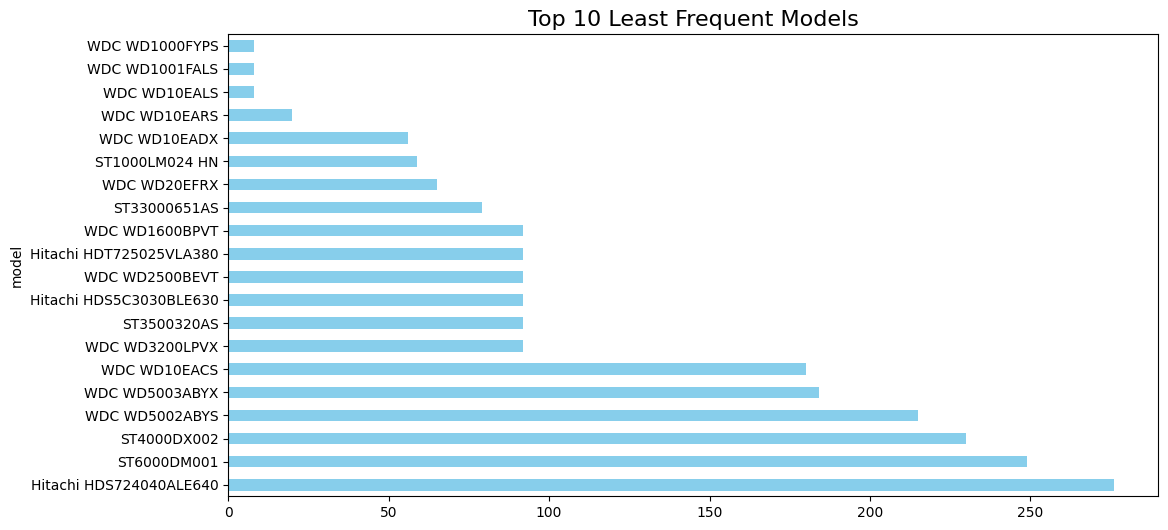

In [ ]:
train_metadata.groupby('model')["model"].value_counts().sort_values(ascending=False).tail(20).plot(kind='barh', figsize=(12,6), color='skyblue')
plt.title('Top 10 Least Frequent Models', fontsize=16)

In [ ]:
train_metadata.groupby('failure')["failure"].value_counts()/ len(train_metadata)

failure
0    0.999947
1    0.000053
Name: count, dtype: float64

In [ ]:
train_metadata['capacity_bytes'].describe()

count    6.589448e+06
mean     4.301728e+12
std      1.426980e+12
min      1.600419e+11
25%      4.000787e+12
50%      4.000787e+12
75%      4.000787e+12
max      8.001563e+12
Name: capacity_bytes, dtype: float64

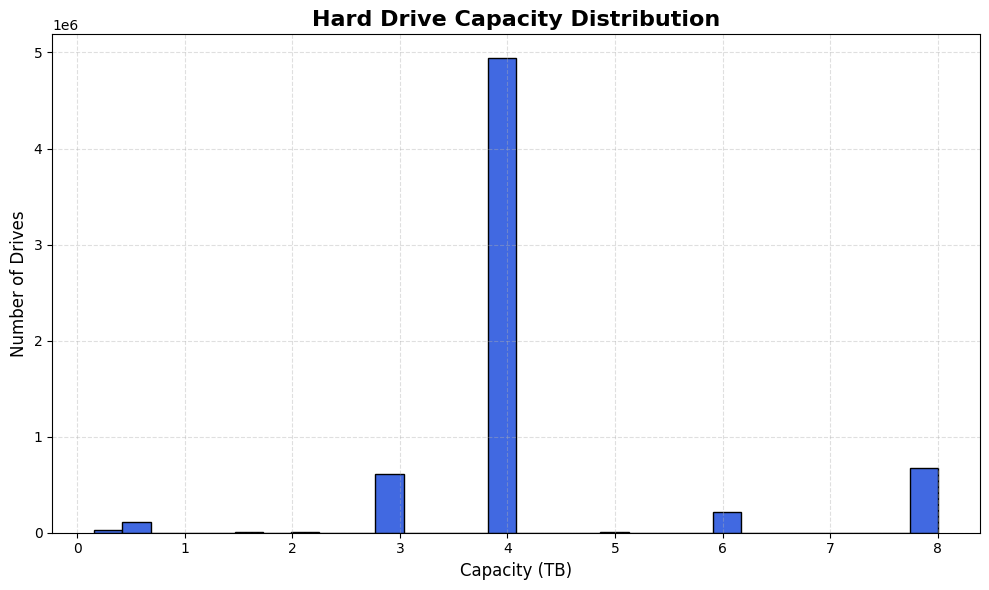

In [ ]:
capacity_tb = train_metadata['capacity_bytes'] / 1_000_000_000_000

plt.figure(figsize=(10,6))

plt.hist(
    capacity_tb,
    bins=30,
    color='royalblue',
    edgecolor='black'
)

plt.title(
    'Hard Drive Capacity Distribution',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Capacity (TB)', fontsize=12)
plt.ylabel('Number of Drives', fontsize=12)

plt.grid(
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()

plt.show()

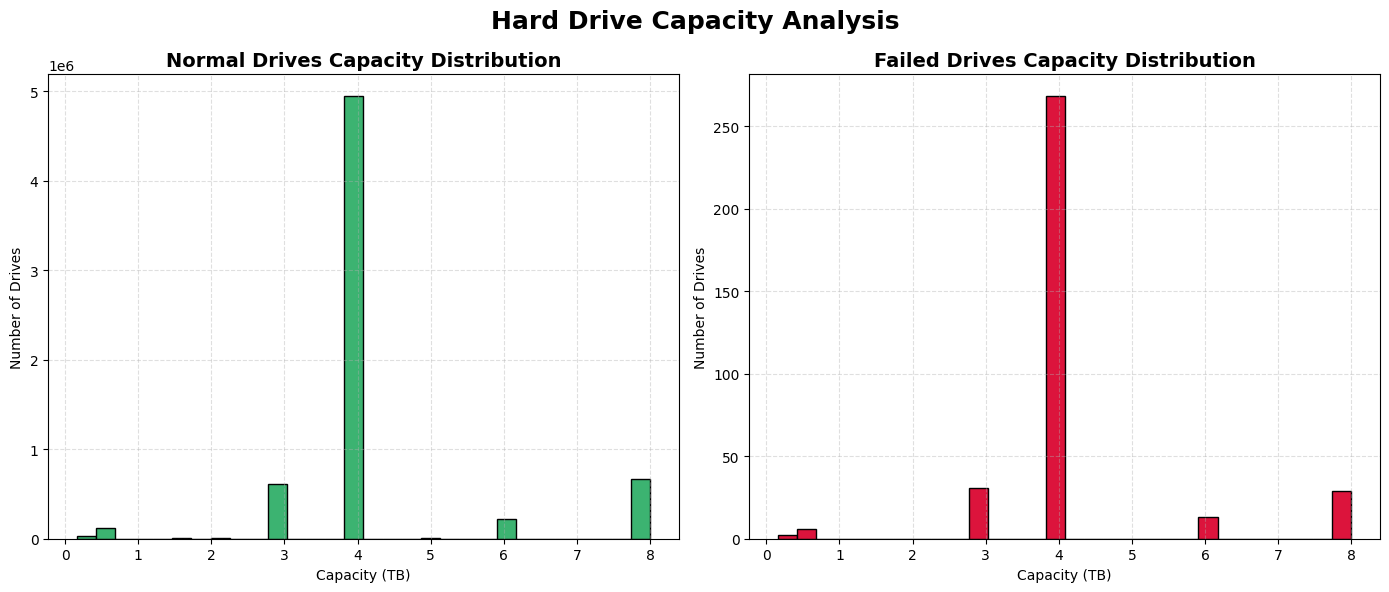

In [ ]:
failed_capacity = train_metadata.loc[ train_metadata['failure'] == 1, 'capacity_bytes' ] / 1_000_000_000_000


normal_capacity = train_metadata.loc[ train_metadata['failure'] == 0, 'capacity_bytes' ] / 1_000_000_000_000


fig, axes = plt.subplots(1, 2, figsize=(14,6))

axes[0].hist(
    normal_capacity,
    bins=30,
    edgecolor='black',
    color='mediumseagreen'
)

axes[0].set_title(
    'Normal Drives Capacity Distribution',
    fontsize=14,
    fontweight='bold'
)

axes[0].set_xlabel('Capacity (TB)')
axes[0].set_ylabel('Number of Drives')

axes[0].grid(
    linestyle='--',
    alpha=0.4
)


axes[1].hist(
    failed_capacity,
    bins=30,
    edgecolor='black',
    color='crimson'
)

axes[1].set_title(
    'Failed Drives Capacity Distribution',
    fontsize=14,
    fontweight='bold'
)

axes[1].set_xlabel('Capacity (TB)')
axes[1].set_ylabel('Number of Drives')

axes[1].grid(
    linestyle='--',
    alpha=0.4
)


plt.suptitle(
    'Hard Drive Capacity Analysis',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

<Axes: ylabel='date'>

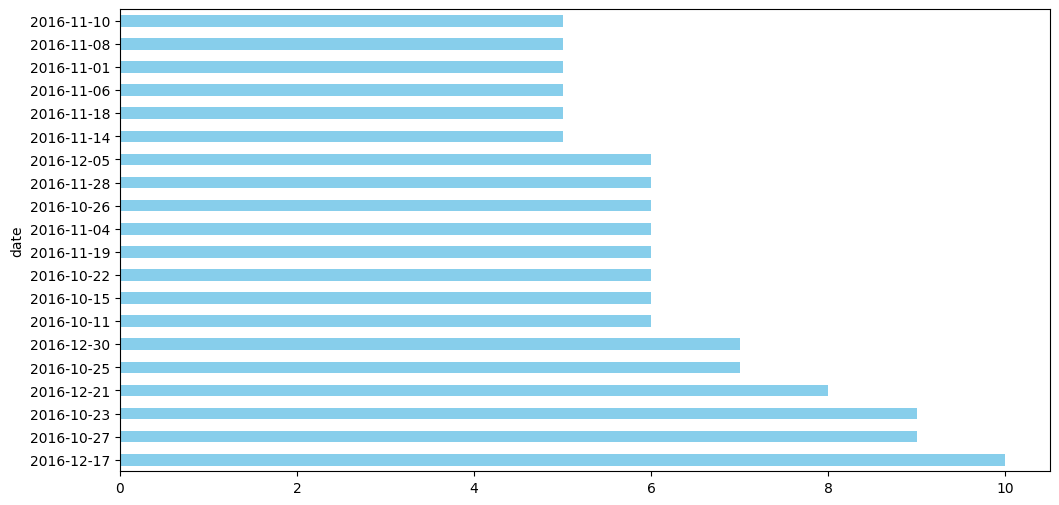

In [ ]:
train_metadata.loc[train_metadata['failure'] == 1]\
    .groupby('date')["date"]\
    .value_counts()\
    .sort_values(ascending=False).head(20).plot(kind='barh', figsize=(12,6), color='skyblue')

In [ ]:
failed = cleaned_df[train_metadata['failure'] == 1]
healthy = cleaned_df[train_metadata['failure'] == 0]

temp_df = pd.concat([failed, healthy.sample(5000)]).reset_index(drop=True)


In [ ]:
sns.pairplot(
    temp_df,
    hue='failure'
)